# ======================
# 全局设置
# ======================

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns


plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

# ======================
# 第一步：读取数据与变量选择
# ======================

In [3]:
print("="*70)
print("第一步：读取数据并选择聚类变量")
print("="*70)

df = pd.read_csv("./data/charls_intermediate_updated.csv")
print(f"✅ 数据读取成功！样本量：{len(df)}，变量数：{len(df.columns)}")

# 仅保留8个健康/功能核心变量，去掉行为类噪音变量
cluster_vars = [
    'chronic_count',   # 慢性病数量（越高越差）
    'adl_score',       # ADL功能障碍得分（越高越差）
    'vision_score',    # 视力自评（越高越好）
    'hearing_score',   # 听力自评（越高越好）
    'pain_level',      # 疼痛程度（越高越差）
    'srh',             # 自评健康（越高越好）
    'cesd_score',      # 抑郁程度（越高越差）
    'cognition_total'  # 认知功能（越高越好）
]

missing_vars = [var for var in cluster_vars if var not in df.columns]
if missing_vars:
    print(f" 以下变量不存在：{missing_vars}")
    raise ValueError("聚类变量缺失")
print(f"✅ {len(cluster_vars)}个核心聚类变量验证通过")

X = df[cluster_vars].values

第一步：读取数据并选择聚类变量
✅ 数据读取成功！样本量：17562，变量数：66
✅ 8个核心聚类变量验证通过


# ======================
# 第二步：数据标准化
# ======================

In [4]:
print("\n" + "="*70)
print("第二步：数据标准化")
print("="*70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ 数据标准化完成")



第二步：数据标准化
✅ 数据标准化完成


# ======================
# 第三步：PCA降维
# ======================

In [5]:
print("\n" + "="*70)
print("第三步：PCA降维分析")
print("="*70)

pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_scaled)

print("各主成分方差解释率：")
for i in range(len(cluster_vars)):
    cum = np.sum(pca_full.explained_variance_ratio_[:i+1])
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]:.1%} (累积: {cum:.1%})")

# 保留累积方差65%的主成分
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.65) + 1
print(f"\n✅ 选择前{n_components}个主成分（累积方差解释率：{cumulative_variance[n_components-1]:.2%}）")

pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"✅ PCA降维完成，数据形状：{X_pca.shape}")



第三步：PCA降维分析
各主成分方差解释率：
  PC1: 34.5% (累积: 34.5%)
  PC2: 13.1% (累积: 47.7%)
  PC3: 11.6% (累积: 59.2%)
  PC4: 10.4% (累积: 69.6%)
  PC5: 8.6% (累积: 78.2%)
  PC6: 7.6% (累积: 85.8%)
  PC7: 7.2% (累积: 93.0%)
  PC8: 7.0% (累积: 100.0%)

✅ 选择前4个主成分（累积方差解释率：69.64%）
✅ PCA降维完成，数据形状：(17562, 4)



# ======================
# 第四步：确定最佳K
# ======================


第四步：确定最佳聚类数K
  K=2: 惯性=66236.8, 轮廓系数=0.323
  K=3: 惯性=54440.3, 轮廓系数=0.246
  K=4: 惯性=44840.7, 轮廓系数=0.262
  K=5: 惯性=39624.6, 轮廓系数=0.235
  K=6: 惯性=35922.1, 轮廓系数=0.233
  K=7: 惯性=33027.8, 轮廓系数=0.219
  K=8: 惯性=30602.2, 轮廓系数=0.224

✅ 轮廓系数最高的K = 2 (轮廓系数 = 0.323)


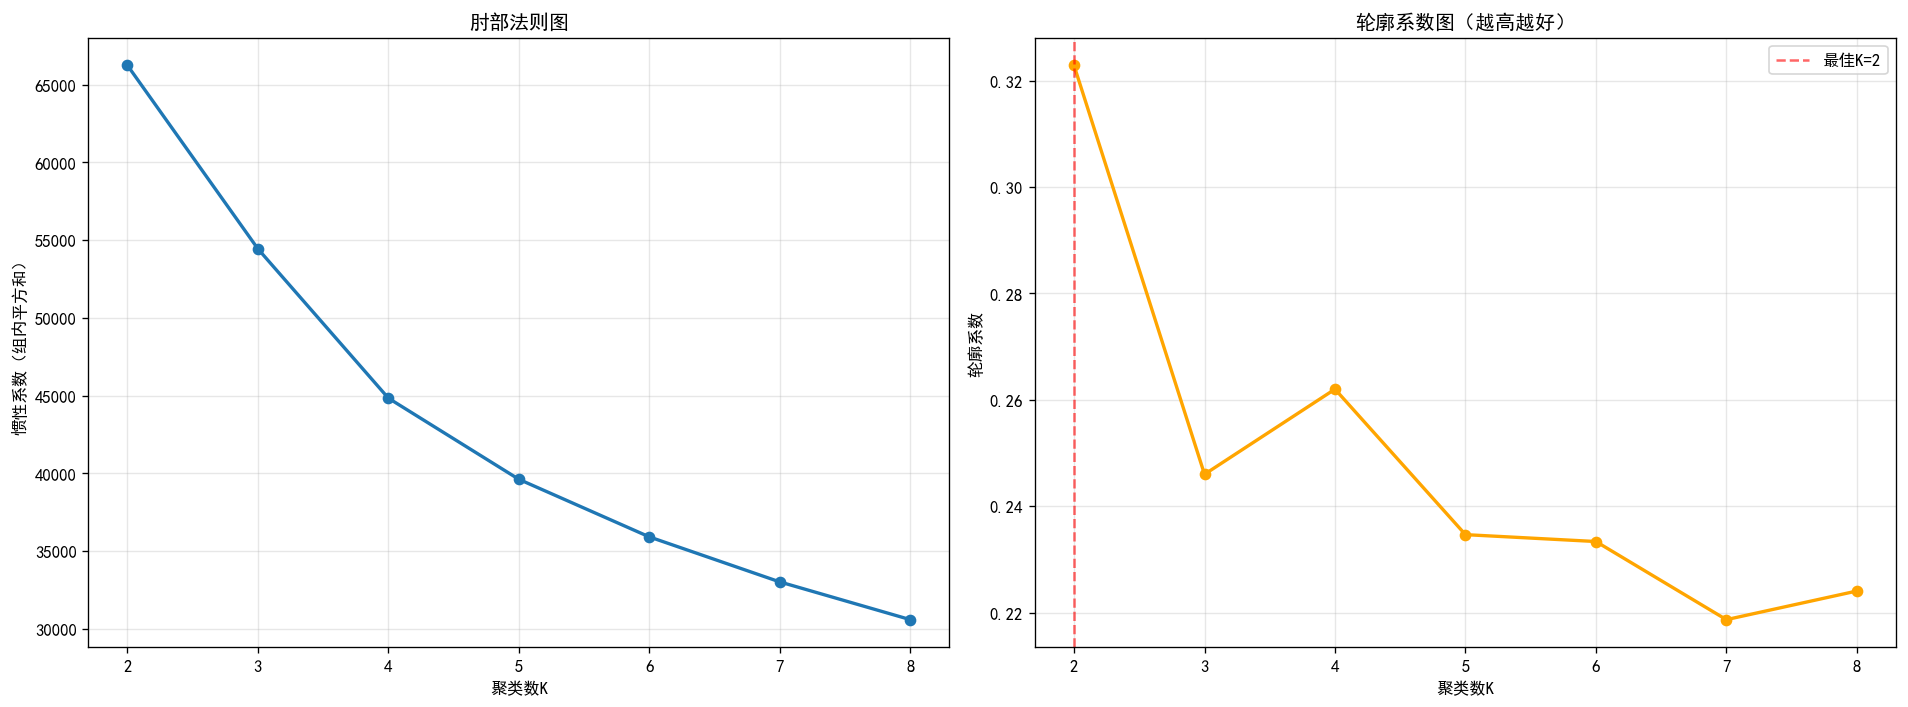


第四步：确定最佳聚类数K
  K=2: 惯性=66236.8, 轮廓系数=0.323
  K=3: 惯性=54440.3, 轮廓系数=0.246
  K=4: 惯性=44840.7, 轮廓系数=0.262
  K=5: 惯性=39624.6, 轮廓系数=0.235
  K=6: 惯性=35922.1, 轮廓系数=0.233
  K=7: 惯性=33027.8, 轮廓系数=0.219
  K=8: 惯性=30602.2, 轮廓系数=0.224

✅ 轮廓系数最高的K = 2 (轮廓系数 = 0.323)


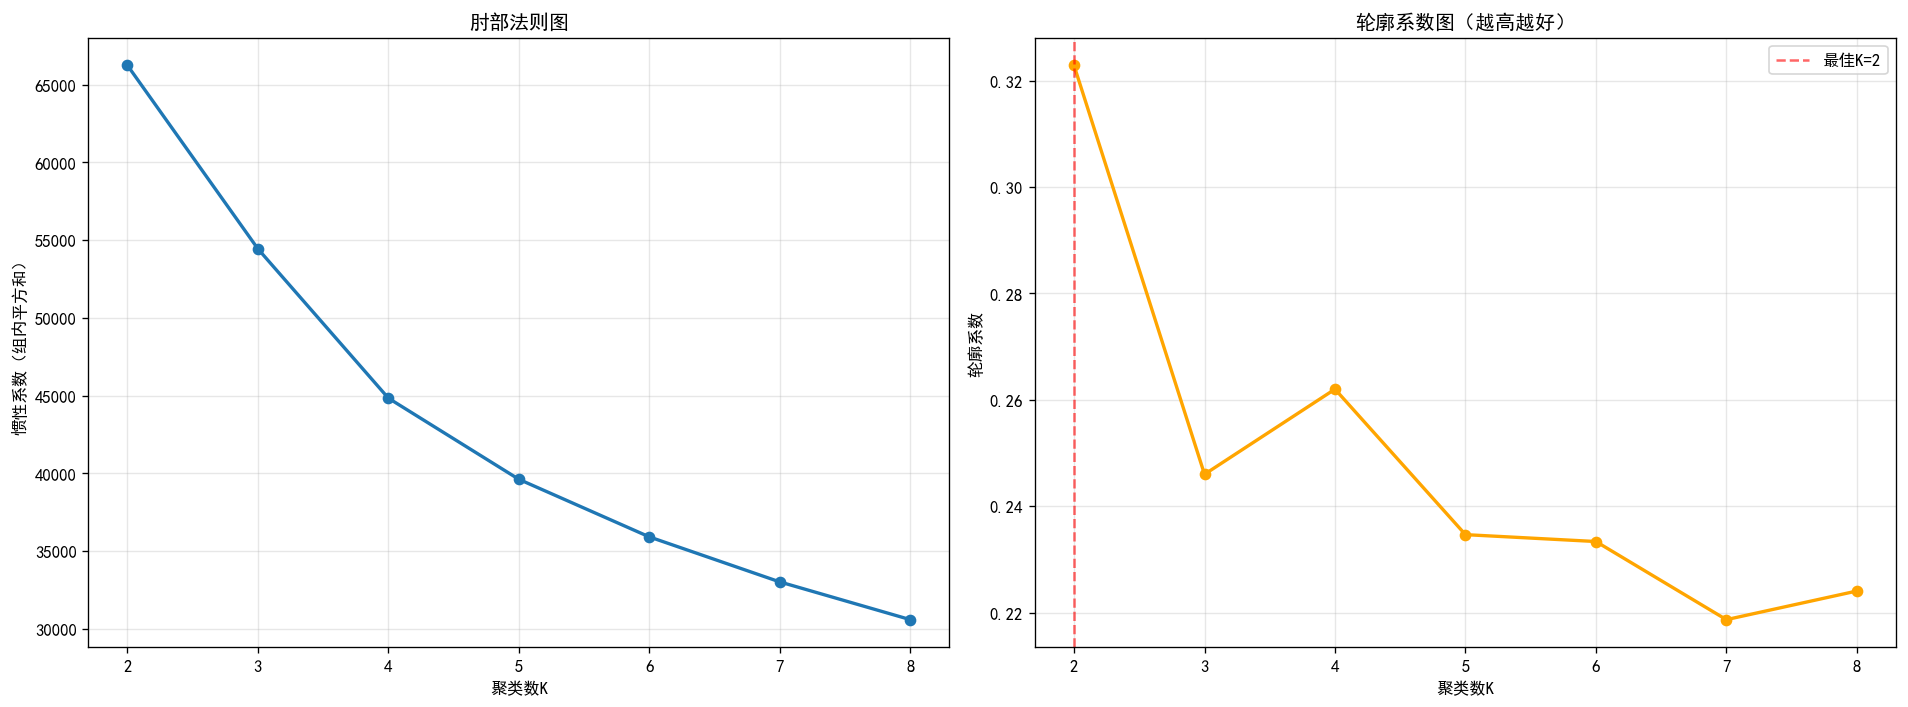

In [6]:
print("\n" + "="*70)
print("第四步：确定最佳聚类数K")
print("="*70)

k_range = range(2, 9)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    print(f"  K={k}: 惯性={km.inertia_:.1f}, 轮廓系数={sil_scores[-1]:.3f}")

best_k = k_range[np.argmax(sil_scores)]
print(f"\n✅ 轮廓系数最高的K = {best_k} (轮廓系数 = {max(sil_scores):.3f})")

# 肘部法则 + 轮廓系数双图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(k_range, inertias, 'o-', linewidth=2)
ax1.set_xlabel('聚类数K')
ax1.set_ylabel('惯性系数（组内平方和）')
ax1.set_title('肘部法则图')
ax1.grid(True, alpha=0.3)
ax2.plot(k_range, sil_scores, 'o-', linewidth=2, color='orange')
ax2.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'最佳K={best_k}')
ax2.set_xlabel('聚类数K')
ax2.set_ylabel('轮廓系数')
ax2.set_title('轮廓系数图（越高越好）')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("第四步：确定最佳聚类数K")
print("="*70)

k_range = range(2, 9)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    print(f"  K={k}: 惯性={km.inertia_:.1f}, 轮廓系数={sil_scores[-1]:.3f}")

best_k = k_range[np.argmax(sil_scores)]
print(f"\n✅ 轮廓系数最高的K = {best_k} (轮廓系数 = {max(sil_scores):.3f})")

# 肘部法则 + 轮廓系数双图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(k_range, inertias, 'o-', linewidth=2)
ax1.set_xlabel('聚类数K')
ax1.set_ylabel('惯性系数（组内平方和）')
ax1.set_title('肘部法则图')
ax1.grid(True, alpha=0.3)
ax2.plot(k_range, sil_scores, 'o-', linewidth=2, color='orange')
ax2.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'最佳K={best_k}')
ax2.set_xlabel('聚类数K')
ax2.set_ylabel('轮廓系数')
ax2.set_title('轮廓系数图（越高越好）')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ======================
# 第五步：K=2 聚类
# ======================



第五步：K=2 聚类
各聚类样本量分布：
  聚类0：6625人（占比37.7%）
  聚类1：10937人（占比62.3%）

轮廓系数：0.323


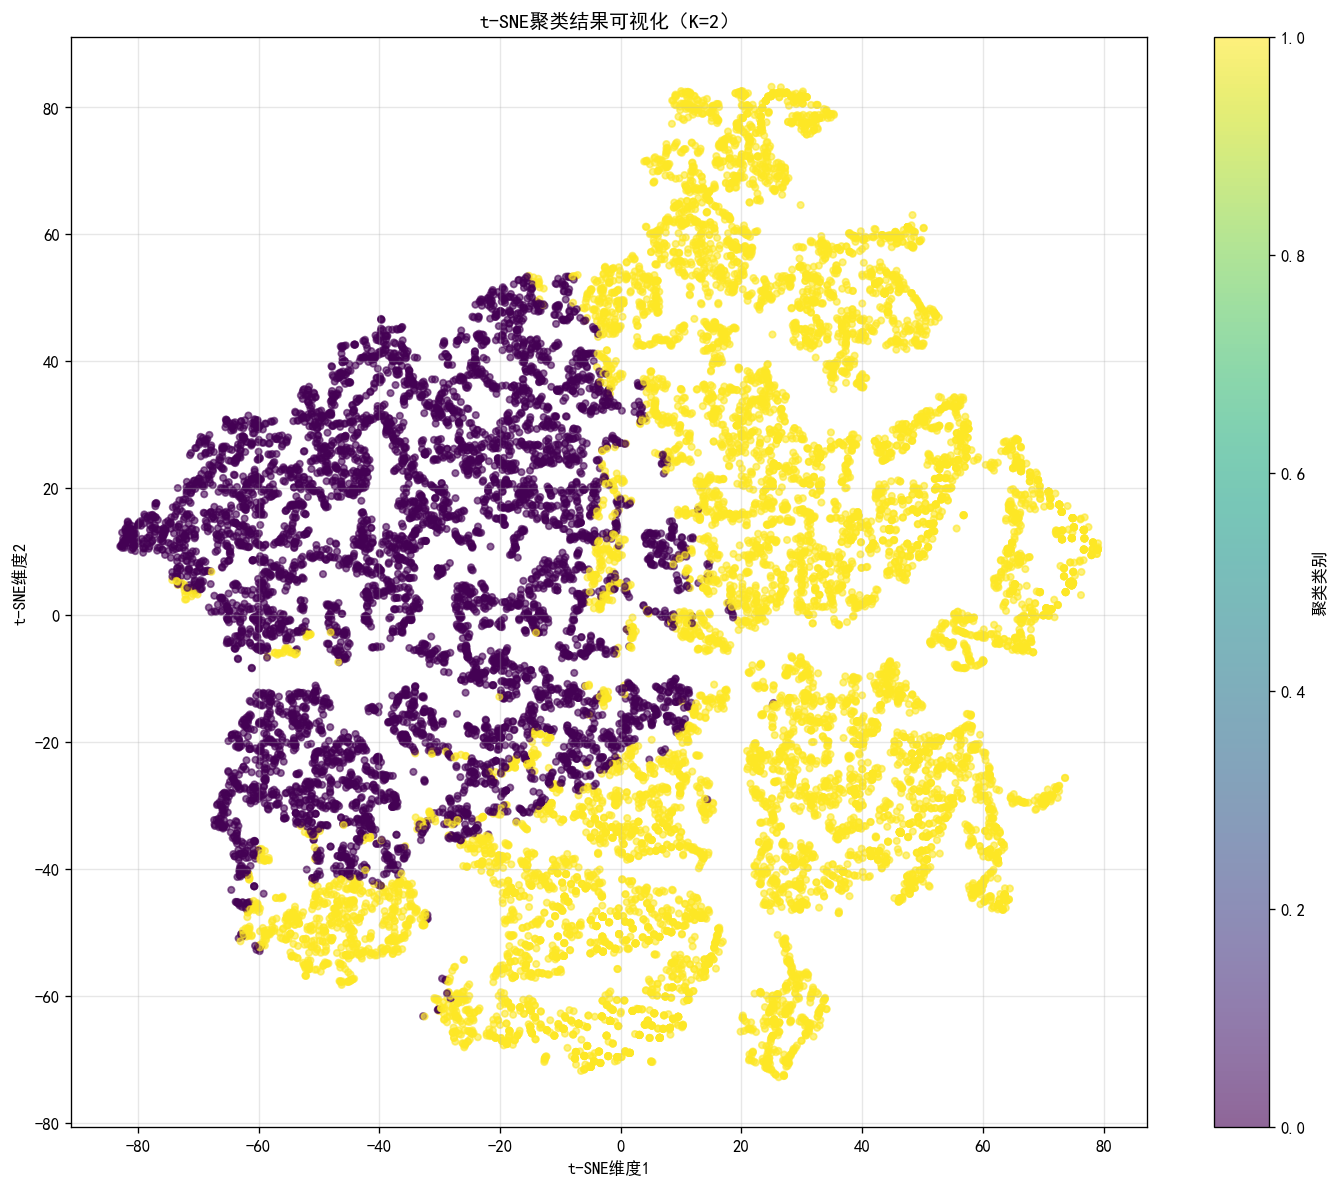


自动命名：
  聚类0 → 衰弱抑郁型
    慢性病数量: 2.23
    ADL功能: 1.30
    视力: 1.78
    听力: 2.01
    疼痛程度: 1.53
    自评健康: 1.34
    抑郁程度: 9.89
    认知功能: 12.27
  聚类1 → 健康良好型
    慢性病数量: 0.84
    ADL功能: 0.08
    视力: 2.65
    听力: 2.77
    疼痛程度: 0.17
    自评健康: 2.39
    抑郁程度: 3.81
    认知功能: 15.93


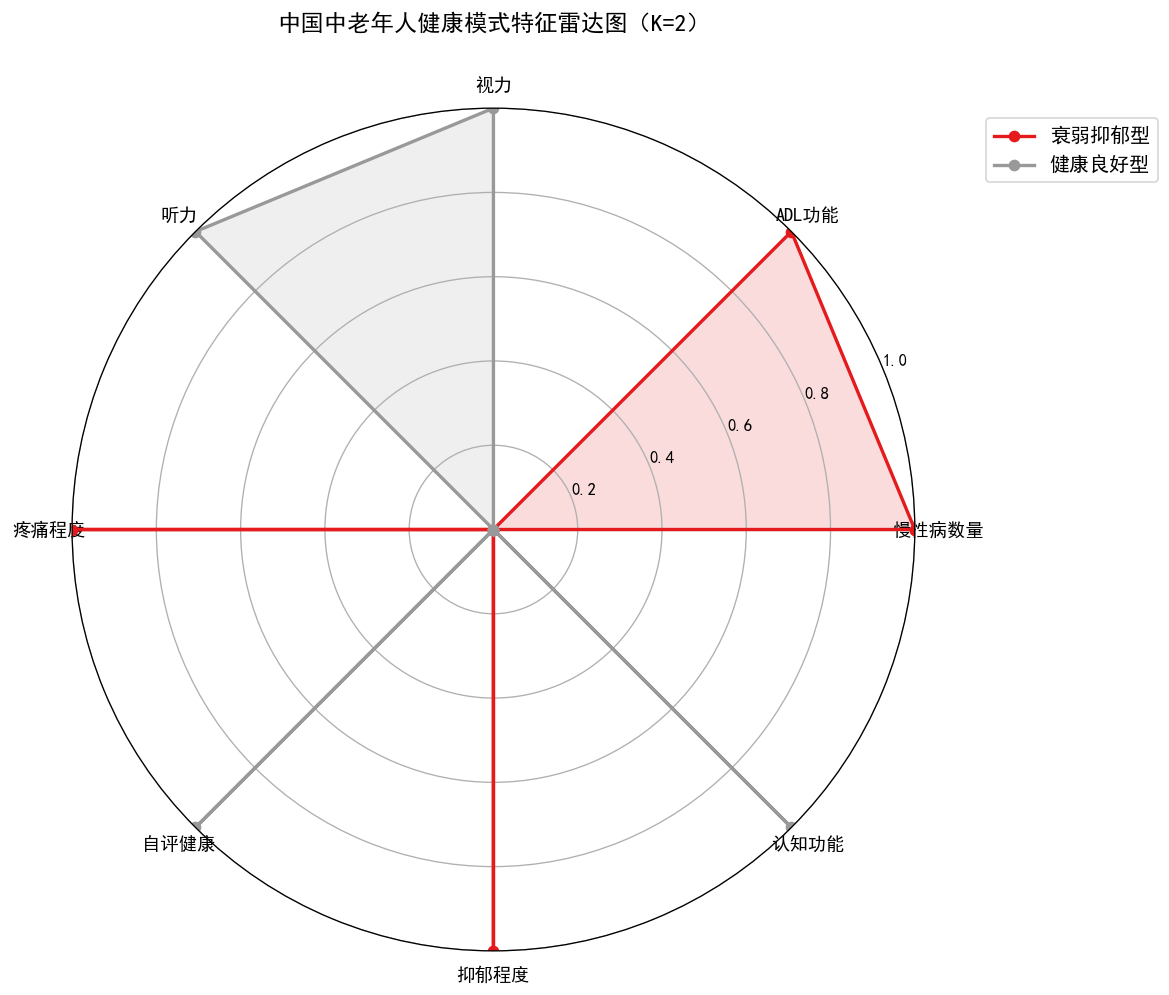


📊 K=2 各聚类核心特征均值表：
       衰弱抑郁型  健康良好型
慢性病数量   2.23   0.84
ADL功能   1.30   0.08
视力      1.78   2.65
听力      2.01   2.77
疼痛程度    1.53   0.17
自评健康    1.34   2.39
抑郁程度    9.89   3.81
认知功能   12.27  15.93


In [8]:
print("\n" + "="*70)
print("第五步：K=2 聚类")
print("="*70)

kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster_2'] = kmeans_2.fit_predict(X_pca)
sil_2 = silhouette_score(X_pca, df['cluster_2'])

print("各聚类样本量分布：")
for i, count in df['cluster_2'].value_counts().sort_index().items():
    print(f"  聚类{i}：{count}人（占比{count/len(df)*100:.1f}%）")
print(f"\n轮廓系数：{sil_2:.3f}")

# K=2 t-SNE
tsne = TSNE(n_components=2, perplexity=50, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['cluster_2'], cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='聚类类别')
plt.title('t-SNE聚类结果可视化（K=2）')
plt.xlabel('t-SNE维度1')
plt.ylabel('t-SNE维度2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# K=2 特征分析
radar_labels = ['慢性病数量', 'ADL功能', '视力', '听力', '疼痛程度', '自评健康', '抑郁程度', '认知功能']

cluster_means_2 = df.groupby('cluster_2')[cluster_vars].mean()
health_score_2 = cluster_means_2['cognition_total'] - cluster_means_2['chronic_count']*2 - cluster_means_2['cesd_score']/2
rank_2 = health_score_2.rank(ascending=False).astype(int) - 1
names_2 = []
for i in range(2):
    r = rank_2[i]
    if r == 0:
        names_2.append('健康良好型')
    else:
        names_2.append('衰弱抑郁型')

print("\n自动命名：")
for i in range(2):
    print(f"  聚类{i} → {names_2[i]}")
    print(f"    慢性病数量: {cluster_means_2.loc[i, 'chronic_count']:.2f}")
    print(f"    ADL功能: {cluster_means_2.loc[i, 'adl_score']:.2f}")
    print(f"    视力: {cluster_means_2.loc[i, 'vision_score']:.2f}")
    print(f"    听力: {cluster_means_2.loc[i, 'hearing_score']:.2f}")
    print(f"    疼痛程度: {cluster_means_2.loc[i, 'pain_level']:.2f}")
    print(f"    自评健康: {cluster_means_2.loc[i, 'srh']:.2f}")
    print(f"    抑郁程度: {cluster_means_2.loc[i, 'cesd_score']:.2f}")
    print(f"    认知功能: {cluster_means_2.loc[i, 'cognition_total']:.2f}")

# K=2 雷达图
cluster_means_2_scaled = (cluster_means_2 - cluster_means_2.min()) / (cluster_means_2.max() - cluster_means_2.min())
N = len(radar_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))
colors_2 = plt.cm.Set1(np.linspace(0, 1, 2))
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
for i in range(2):
    values = cluster_means_2_scaled.loc[i].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=names_2[i], color=colors_2[i])
    ax.fill(angles, values, alpha=0.15, color=colors_2[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1.0])
plt.title('中国中老年人健康模式特征雷达图（K=2）', y=1.08, fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 K=2 各聚类核心特征均值表：")
ft2 = cluster_means_2.T
ft2.columns = names_2
ft2.index = radar_labels
print(ft2.round(2))

# ======================
# 第六步：K=3 聚类
# ======================


第六步：K=3 聚类
各聚类样本量分布：
  聚类0：7634人（占比43.5%）
  聚类1：5535人（占比31.5%）
  聚类2：4393人（占比25.0%）

轮廓系数：0.246


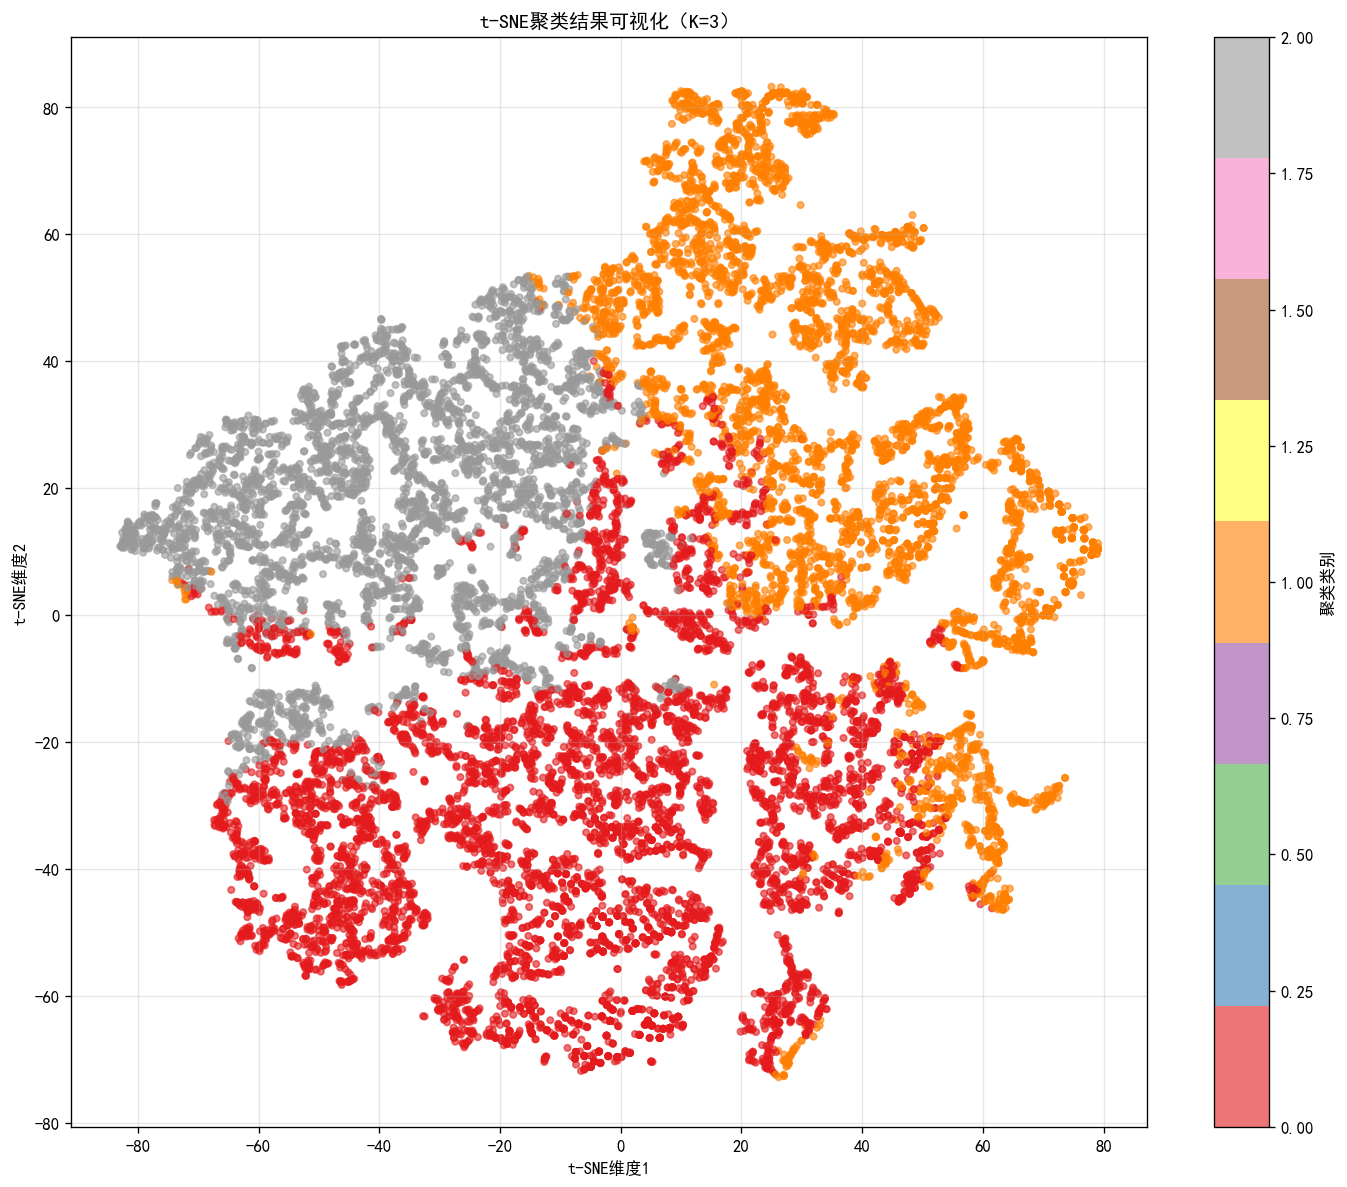


自动命名：

  【一般衰退型】（聚类0）：
    慢性病数量: 1.13
    ADL功能: 0.16
    视力: 1.98
    听力: 2.10
    疼痛程度: 0.29
    自评健康: 1.94
    抑郁程度: 5.02
    认知功能: 14.32

  【健康良好型】（聚类1）：
    慢性病数量: 0.75
    ADL功能: 0.07
    视力: 3.20
    听力: 3.34
    疼痛程度: 0.20
    自评健康: 2.70
    抑郁程度: 3.55
    认知功能: 16.83

  【衰弱抑郁型】（聚类2）：
    慢性病数量: 2.55
    ADL功能: 1.80
    视力: 1.81
    听力: 2.08
    疼痛程度: 1.99
    自评健康: 1.20
    抑郁程度: 11.20
    认知功能: 12.06


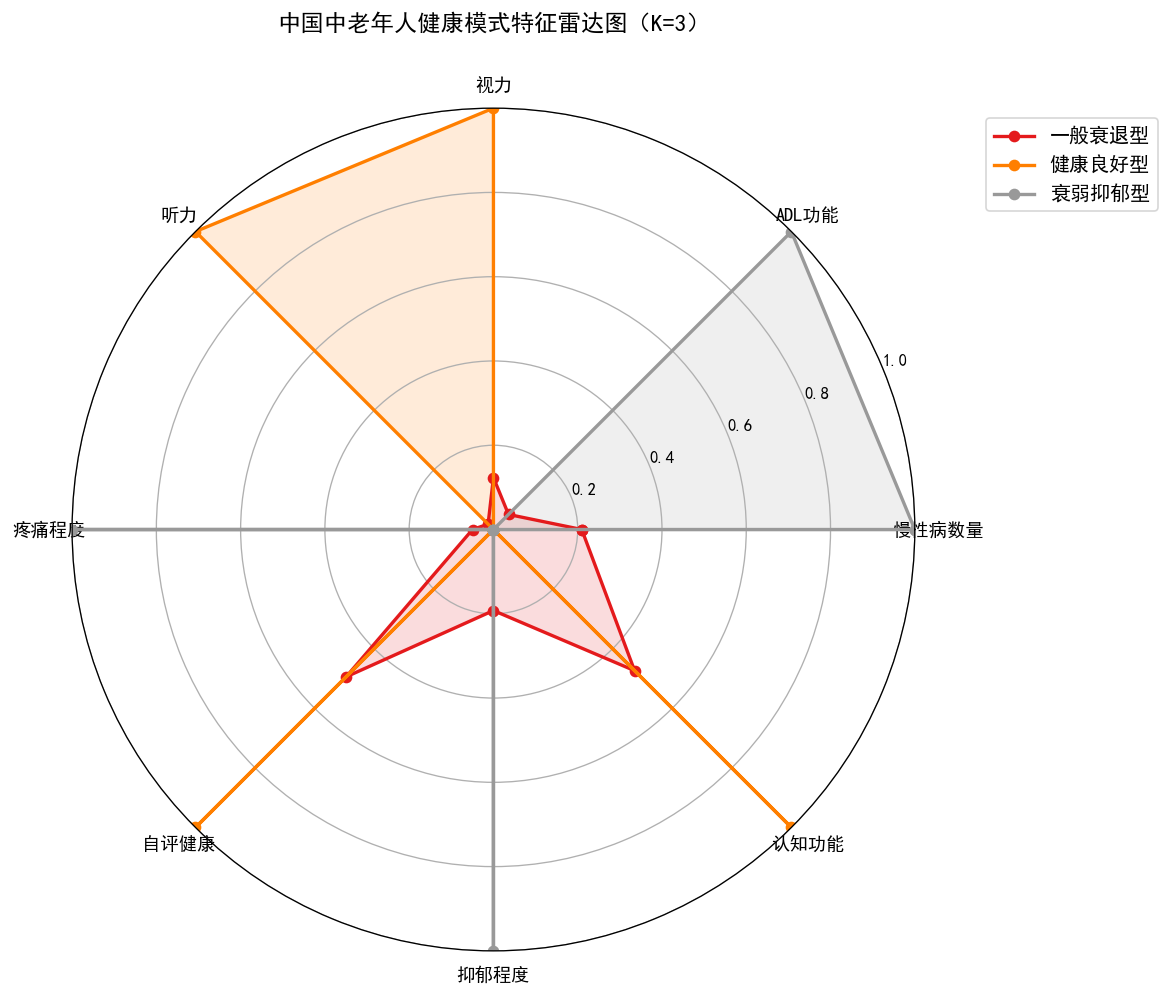


📊 K=3 各聚类核心特征均值表：
       一般衰退型  健康良好型  衰弱抑郁型
慢性病数量   1.13   0.75   2.55
ADL功能   0.16   0.07   1.80
视力      1.98   3.20   1.81
听力      2.10   3.34   2.08
疼痛程度    0.29   0.20   1.99
自评健康    1.94   2.70   1.20
抑郁程度    5.02   3.55  11.20
认知功能   14.32  16.83  12.06

📅 K=3 各聚类平均年龄：
       mean   std
一般衰退型  68.8  10.1
健康良好型  64.7   8.9
衰弱抑郁型  71.0  10.3

 K=3 各聚类性别分布（%）：
         男性    女性
一般衰退型  49.1  50.9
健康良好型  55.5  44.5
衰弱抑郁型  36.3  63.7


In [9]:
print("\n" + "="*70)
print("第六步：K=3 聚类")
print("="*70)

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_3'] = kmeans_3.fit_predict(X_pca)
sil_3 = silhouette_score(X_pca, df['cluster_3'])

print("各聚类样本量分布：")
for i, count in df['cluster_3'].value_counts().sort_index().items():
    print(f"  聚类{i}：{count}人（占比{count/len(df)*100:.1f}%）")
print(f"\n轮廓系数：{sil_3:.3f}")

# K=3 t-SNE
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['cluster_3'], cmap='Set1', alpha=0.6, s=15)
plt.colorbar(scatter, label='聚类类别')
plt.title('t-SNE聚类结果可视化（K=3）')
plt.xlabel('t-SNE维度1')
plt.ylabel('t-SNE维度2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# K=3 特征分析
cluster_means_3 = df.groupby('cluster_3')[cluster_vars].mean()
health_score_3 = cluster_means_3['cognition_total'] - cluster_means_3['chronic_count']*2 - cluster_means_3['cesd_score']/2
rank_3 = health_score_3.rank(ascending=False).astype(int) - 1
names_3 = []
for i in range(3):
    r = rank_3[i]
    if r == 0:
        names_3.append('健康良好型')
    elif r == 1:
        names_3.append('一般衰退型')
    else:
        names_3.append('衰弱抑郁型')

print("\n自动命名：")
for i in range(3):
    print(f"\n  【{names_3[i]}】（聚类{i}）：")
    for j, var in enumerate(cluster_vars):
        print(f"    {radar_labels[j]}: {cluster_means_3.loc[i, var]:.2f}")

# K=3 雷达图
cluster_means_3_scaled = (cluster_means_3 - cluster_means_3.min()) / (cluster_means_3.max() - cluster_means_3.min())
colors_3 = plt.cm.Set1(np.linspace(0, 1, 3))
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
for i in range(3):
    values = cluster_means_3_scaled.loc[i].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=names_3[i], color=colors_3[i])
    ax.fill(angles, values, alpha=0.15, color=colors_3[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1.0])
plt.title('中国中老年人健康模式特征雷达图（K=3）', y=1.08, fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 K=3 各聚类核心特征均值表：")
ft3 = cluster_means_3.T
ft3.columns = names_3
ft3.index = radar_labels
print(ft3.round(2))

# K=3 人口统计学
print("\n📅 K=3 各聚类平均年龄：")
age_stats_3 = df.groupby('cluster_3')['age'].agg(['mean', 'std'])
age_stats_3.index = names_3
print(age_stats_3.round(1))

print("\n K=3 各聚类性别分布（%）：")
gender_dist_3 = df.groupby(['cluster_3', 'gender']).size().unstack()
gender_dist_3 = gender_dist_3.div(gender_dist_3.sum(axis=1), axis=0) * 100
gender_dist_3.columns = ['男性', '女性']
gender_dist_3.index = names_3
print(gender_dist_3.round(1))

# ======================
# 第七步：K=4 聚类
# ======================


第七步：K=4 聚类
各聚类样本量分布：
  聚类0：4391人（占比25.0%）
  聚类1：5451人（占比31.0%）
  聚类2：7196人（占比41.0%）
  聚类3：524人（占比3.0%）

轮廓系数：0.262


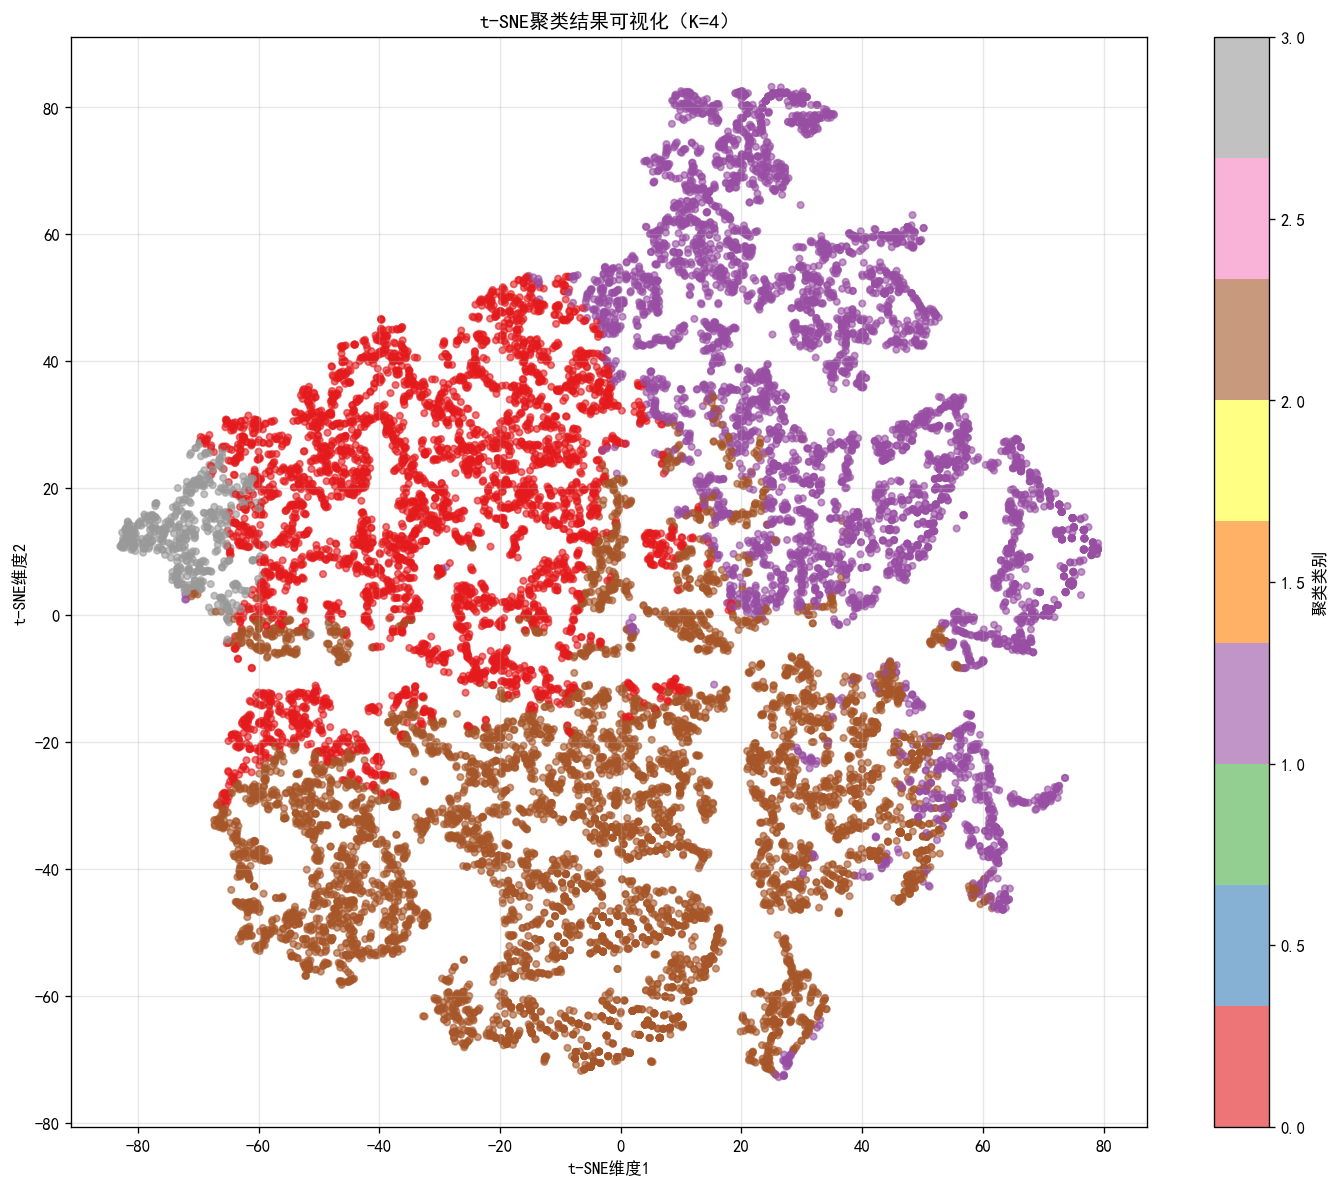


自动命名：

  【认知衰退型】（聚类0）：
    慢性病数量: 2.41
    ADL功能: 0.71
    视力: 1.83
    听力: 2.11
    疼痛程度: 2.00
    自评健康: 1.28
    抑郁程度: 10.96
    认知功能: 12.49

  【健康良好型】（聚类1）：
    慢性病数量: 0.75
    ADL功能: 0.06
    视力: 3.21
    听力: 3.34
    疼痛程度: 0.19
    自评健康: 2.70
    抑郁程度: 3.55
    认知功能: 16.85

  【慢性病灶型】（聚类2）：
    慢性病数量: 1.09
    ADL功能: 0.16
    视力: 1.98
    听力: 2.09
    疼痛程度: 0.21
    自评健康: 1.97
    抑郁程度: 4.76
    认知功能: 14.33

  【衰弱抑郁型】（聚类3）：
    慢性病数量: 2.62
    ADL功能: 9.29
    视力: 1.86
    听力: 2.00
    疼痛程度: 1.41
    自评健康: 0.99
    抑郁程度: 10.36
    认知功能: 10.80


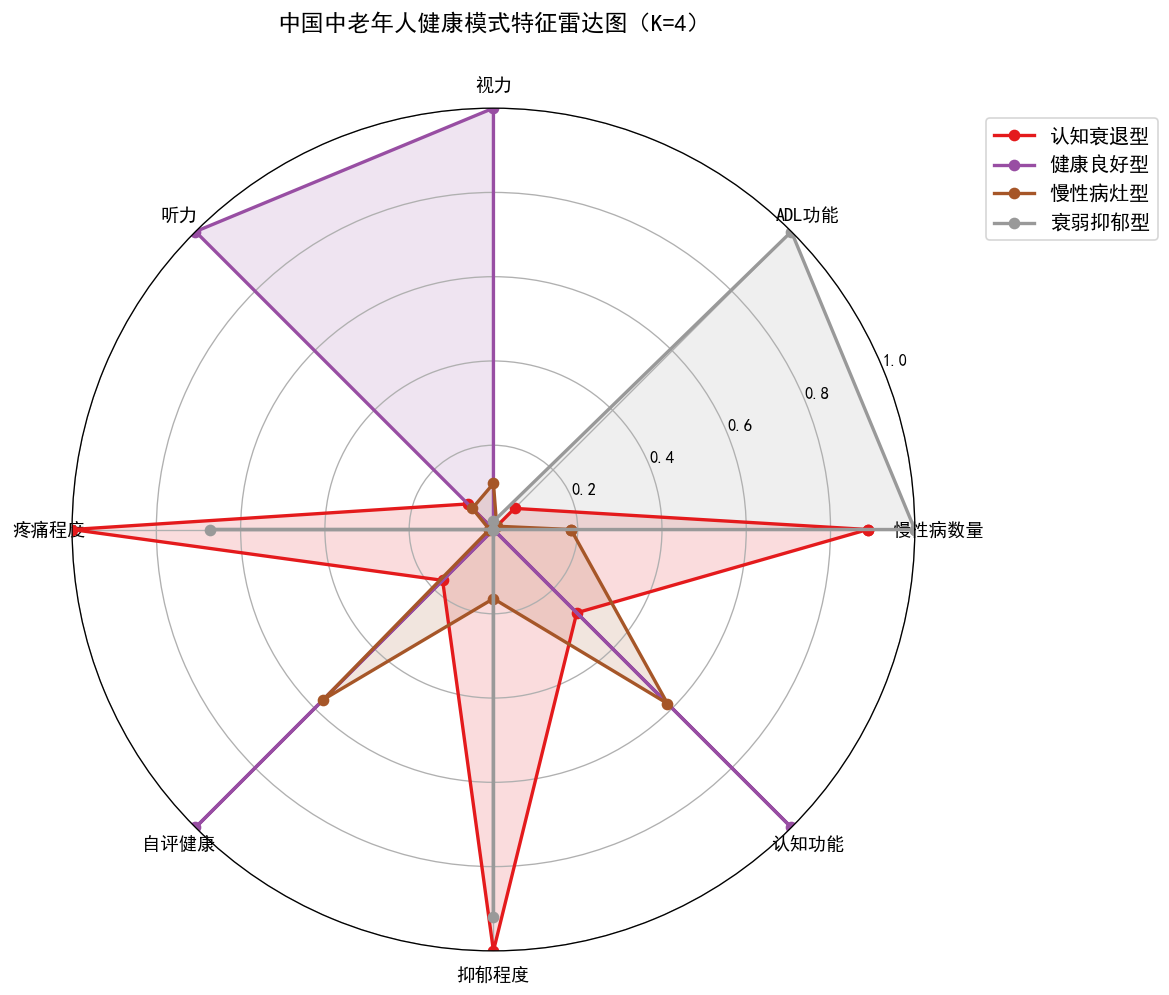


📊 K=4 各聚类核心特征均值表：
       认知衰退型  健康良好型  慢性病灶型  衰弱抑郁型
慢性病数量   2.41   0.75   1.09   2.62
ADL功能   0.71   0.06   0.16   9.29
视力      1.83   3.21   1.98   1.86
听力      2.11   3.34   2.09   2.00
疼痛程度    2.00   0.19   0.21   1.41
自评健康    1.28   2.70   1.97   0.99
抑郁程度   10.96   3.55   4.76  10.36
认知功能   12.49  16.85  14.33  10.80

📅 K=4 各聚类平均年龄：
       mean   std
认知衰退型  69.6   9.7
健康良好型  64.6   8.9
慢性病灶型  69.0  10.2
衰弱抑郁型  78.6  11.5

👫 K=4 各聚类性别分布（%）：
         男性    女性
认知衰退型  35.9  64.1
健康良好型  55.5  44.5
慢性病灶型  49.7  50.3
衰弱抑郁型  45.4  54.6


In [10]:
print("\n" + "="*70)
print("第七步：K=4 聚类")
print("="*70)

kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_4'] = kmeans_4.fit_predict(X_pca)
sil_4 = silhouette_score(X_pca, df['cluster_4'])

print("各聚类样本量分布：")
for i, count in df['cluster_4'].value_counts().sort_index().items():
    print(f"  聚类{i}：{count}人（占比{count/len(df)*100:.1f}%）")
print(f"\n轮廓系数：{sil_4:.3f}")

# K=4 t-SNE
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['cluster_4'], cmap='Set1', alpha=0.6, s=15)
plt.colorbar(scatter, label='聚类类别')
plt.title('t-SNE聚类结果可视化（K=4）')
plt.xlabel('t-SNE维度1')
plt.ylabel('t-SNE维度2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# K=4 特征分析
cluster_means_4 = df.groupby('cluster_4')[cluster_vars].mean()
health_score_4 = cluster_means_4['cognition_total'] - cluster_means_4['chronic_count']*2 - cluster_means_4['cesd_score']/2
rank_4 = health_score_4.rank(ascending=False).astype(int) - 1
names_4 = [''] * 4
for i in range(4):
    r = rank_4[i]
    if r == 0:
        names_4[i] = '健康良好型'
    elif r == 1:
        names_4[i] = '慢性病灶型'
    elif r == 2:
        names_4[i] = '认知衰退型'
    else:
        names_4[i] = '衰弱抑郁型'

print("\n自动命名：")
for i in range(4):
    print(f"\n  【{names_4[i]}】（聚类{i}）：")
    for j, var in enumerate(cluster_vars):
        print(f"    {radar_labels[j]}: {cluster_means_4.loc[i, var]:.2f}")

# K=4 雷达图
cluster_means_4_scaled = (cluster_means_4 - cluster_means_4.min()) / (cluster_means_4.max() - cluster_means_4.min())
colors_4 = plt.cm.Set1(np.linspace(0, 1, 4))
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
for i in range(4):
    values = cluster_means_4_scaled.loc[i].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=names_4[i], color=colors_4[i])
    ax.fill(angles, values, alpha=0.15, color=colors_4[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1.0])
plt.title('中国中老年人健康模式特征雷达图（K=4）', y=1.08, fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 K=4 各聚类核心特征均值表：")
ft4 = cluster_means_4.T
ft4.columns = names_4
ft4.index = radar_labels
print(ft4.round(2))

# K=4 人口统计学
print("\n📅 K=4 各聚类平均年龄：")
age_stats_4 = df.groupby('cluster_4')['age'].agg(['mean', 'std'])
age_stats_4.index = names_4
print(age_stats_4.round(1))

print("\n👫 K=4 各聚类性别分布（%）：")
gender_dist_4 = df.groupby(['cluster_4', 'gender']).size().unstack()
gender_dist_4 = gender_dist_4.div(gender_dist_4.sum(axis=1), axis=0) * 100
gender_dist_4.columns = ['男性', '女性']
gender_dist_4.index = names_4
print(gender_dist_4.round(1))


# ======================
# 第八步：K=2 vs K=3 vs K=4 综合对比
# ======================

In [11]:
print("\n" + "="*70)
print("K=2 vs K=3 vs K=4 综合对比")
print("="*70)

print(f"\n{'指标':<15} {'K=2':<15} {'K=3':<15} {'K=4':<15}")
print("-" * 60)
print(f"{'轮廓系数':<15} {sil_2:.3f}{'':<12} {sil_3:.3f}{'':<12} {sil_4:.3f}")

counts_2 = df['cluster_2'].value_counts().sort_index()
counts_3 = df['cluster_3'].value_counts().sort_index()
counts_4 = df['cluster_4'].value_counts().sort_index()
print(f"{'样本分布':<15} {' / '.join([f'{c}人({c/len(df)*100:.0f}%)' for c in counts_2]):<15} {' / '.join([f'{c}人({c/len(df)*100:.0f}%)' for c in counts_3]):<15} {' / '.join([f'{c}人({c/len(df)*100:.0f}%)' for c in counts_4])}")
print(f"{'聚类名称':<15} {' / '.join(names_2):<15} {' / '.join(names_3):<15} {' / '.join(names_4)}")

# 质量评级
print(f"\n方案评估：")
for k, sil in [(2, sil_2), (3, sil_3), (4, sil_4)]:
    if sil > 0.4:
        quality = "优秀"
    elif sil > 0.25:
        quality = "良好"
    elif sil > 0.1:
        quality = "一般"
    else:
        quality = "较差"
    print(f"  K={k}: 轮廓系数={sil:.3f} ({quality})")

# 最终推荐(实际解释意义来看，k=3的解释效果最好。故虽然轮廓系数在三者中最低，还是选择k=3)
'''all_sil = {2: sil_2, 3: sil_3, 4: sil_4}
best = max(all_sil, key=all_sil.get)
print(f"\n✅ 最佳轮廓系数：K={best} ({all_sil[best]:.3f})")
if best == 3:
    print("   推荐以 K=3 作为主结果，聚类区分度最佳，三个类别代表健康梯度的三个层次")
elif best == 4:
    print("   推荐以 K=4 作为主结果，提供更细粒度的健康分类")
else:
    print("   推荐以 K=2 作为主结果，聚类最简洁清晰")'''
print("   推荐以 K=3 作为主结果，聚类区分度最佳，三个类别代表健康梯度的三个层次")


K=2 vs K=3 vs K=4 综合对比

指标              K=2             K=3             K=4            
------------------------------------------------------------
轮廓系数            0.323             0.246             0.262
样本分布            6625人(38%) / 10937人(62%) 7634人(43%) / 5535人(32%) / 4393人(25%) 4391人(25%) / 5451人(31%) / 7196人(41%) / 524人(3%)
聚类名称            衰弱抑郁型 / 健康良好型   一般衰退型 / 健康良好型 / 衰弱抑郁型 认知衰退型 / 健康良好型 / 慢性病灶型 / 衰弱抑郁型

方案评估：
  K=2: 轮廓系数=0.323 (良好)
  K=3: 轮廓系数=0.246 (一般)
  K=4: 轮廓系数=0.262 (良好)
   推荐以 K=3 作为主结果，聚类区分度最佳，三个类别代表健康梯度的三个层次


# ======================
# 第九步：保存结果
# ======================

In [ ]:
print("\n" + "="*70)
print("第九步：保存分析结果")
print("="*70)

df.to_csv("./data/charls_improved_clustered.csv", index=False, encoding='utf-8-sig')

# 保存三个方案各自的特征表
ft2.to_csv("./data/cluster_features_K2.csv", encoding='utf-8-sig')
ft3.to_csv("./data/cluster_features_K3.csv", encoding='utf-8-sig')
ft4.to_csv("./data/cluster_features_K4.csv", encoding='utf-8-sig')
print("✅ 所有结果已保存")

print("\n 聚类分析全部完成！")


# ======================
# 第十步：相关性热力图
# ======================

第十步：聚类变量相关性分析


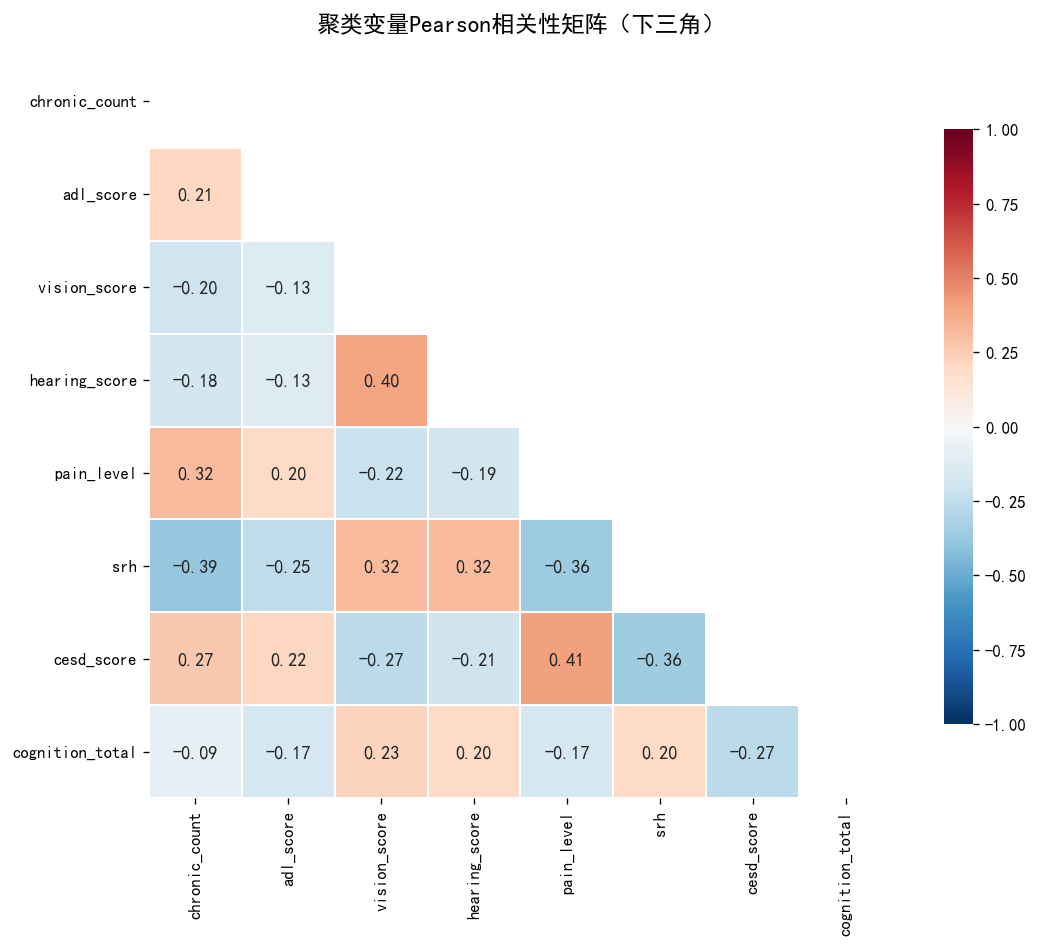

强相关变量对（|r| > 0.3）：
  chronic_count ↔ pain_level: r=0.316 (中等正相关)
  chronic_count ↔ srh: r=-0.388 (中等负相关)
  vision_score ↔ hearing_score: r=0.396 (中等正相关)
  vision_score ↔ srh: r=0.319 (中等正相关)
  hearing_score ↔ srh: r=0.318 (中等正相关)
  pain_level ↔ srh: r=-0.364 (中等负相关)
  pain_level ↔ cesd_score: r=0.407 (中等正相关)
  srh ↔ cesd_score: r=-0.355 (中等负相关)
✅ 相关性分析完成。图中红色=正相关，蓝色=负相关，颜色越深相关性越强。


In [21]:
print(" " + "="*70)
print("第十步：聚类变量相关性分析")
print("="*70)

import seaborn as sns

# 计算8个聚类变量的Pearson相关系数矩阵
corr_matrix = df[cluster_vars].corr(method='pearson')

# 绘制相关性热力图
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 只显示下三角
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=1,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    annot_kws={'fontsize': 11}
)
plt.title('聚类变量Pearson相关性矩阵（下三角）', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 打印强相关对（|r| > 0.3）
print("强相关变量对（|r| > 0.3）：")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            direction = '正相关' if r > 0 else '负相关'
            strength = '强' if abs(r) > 0.5 else '中等'
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r={r:.3f} ({strength}{direction})")

print("✅ 相关性分析完成。图中红色=正相关，蓝色=负相关，颜色越深相关性越强。")

# ======================
# 第十一步续 全局分布直方图+kde
# ======================


第十一步：聚类变量全局分布直方图


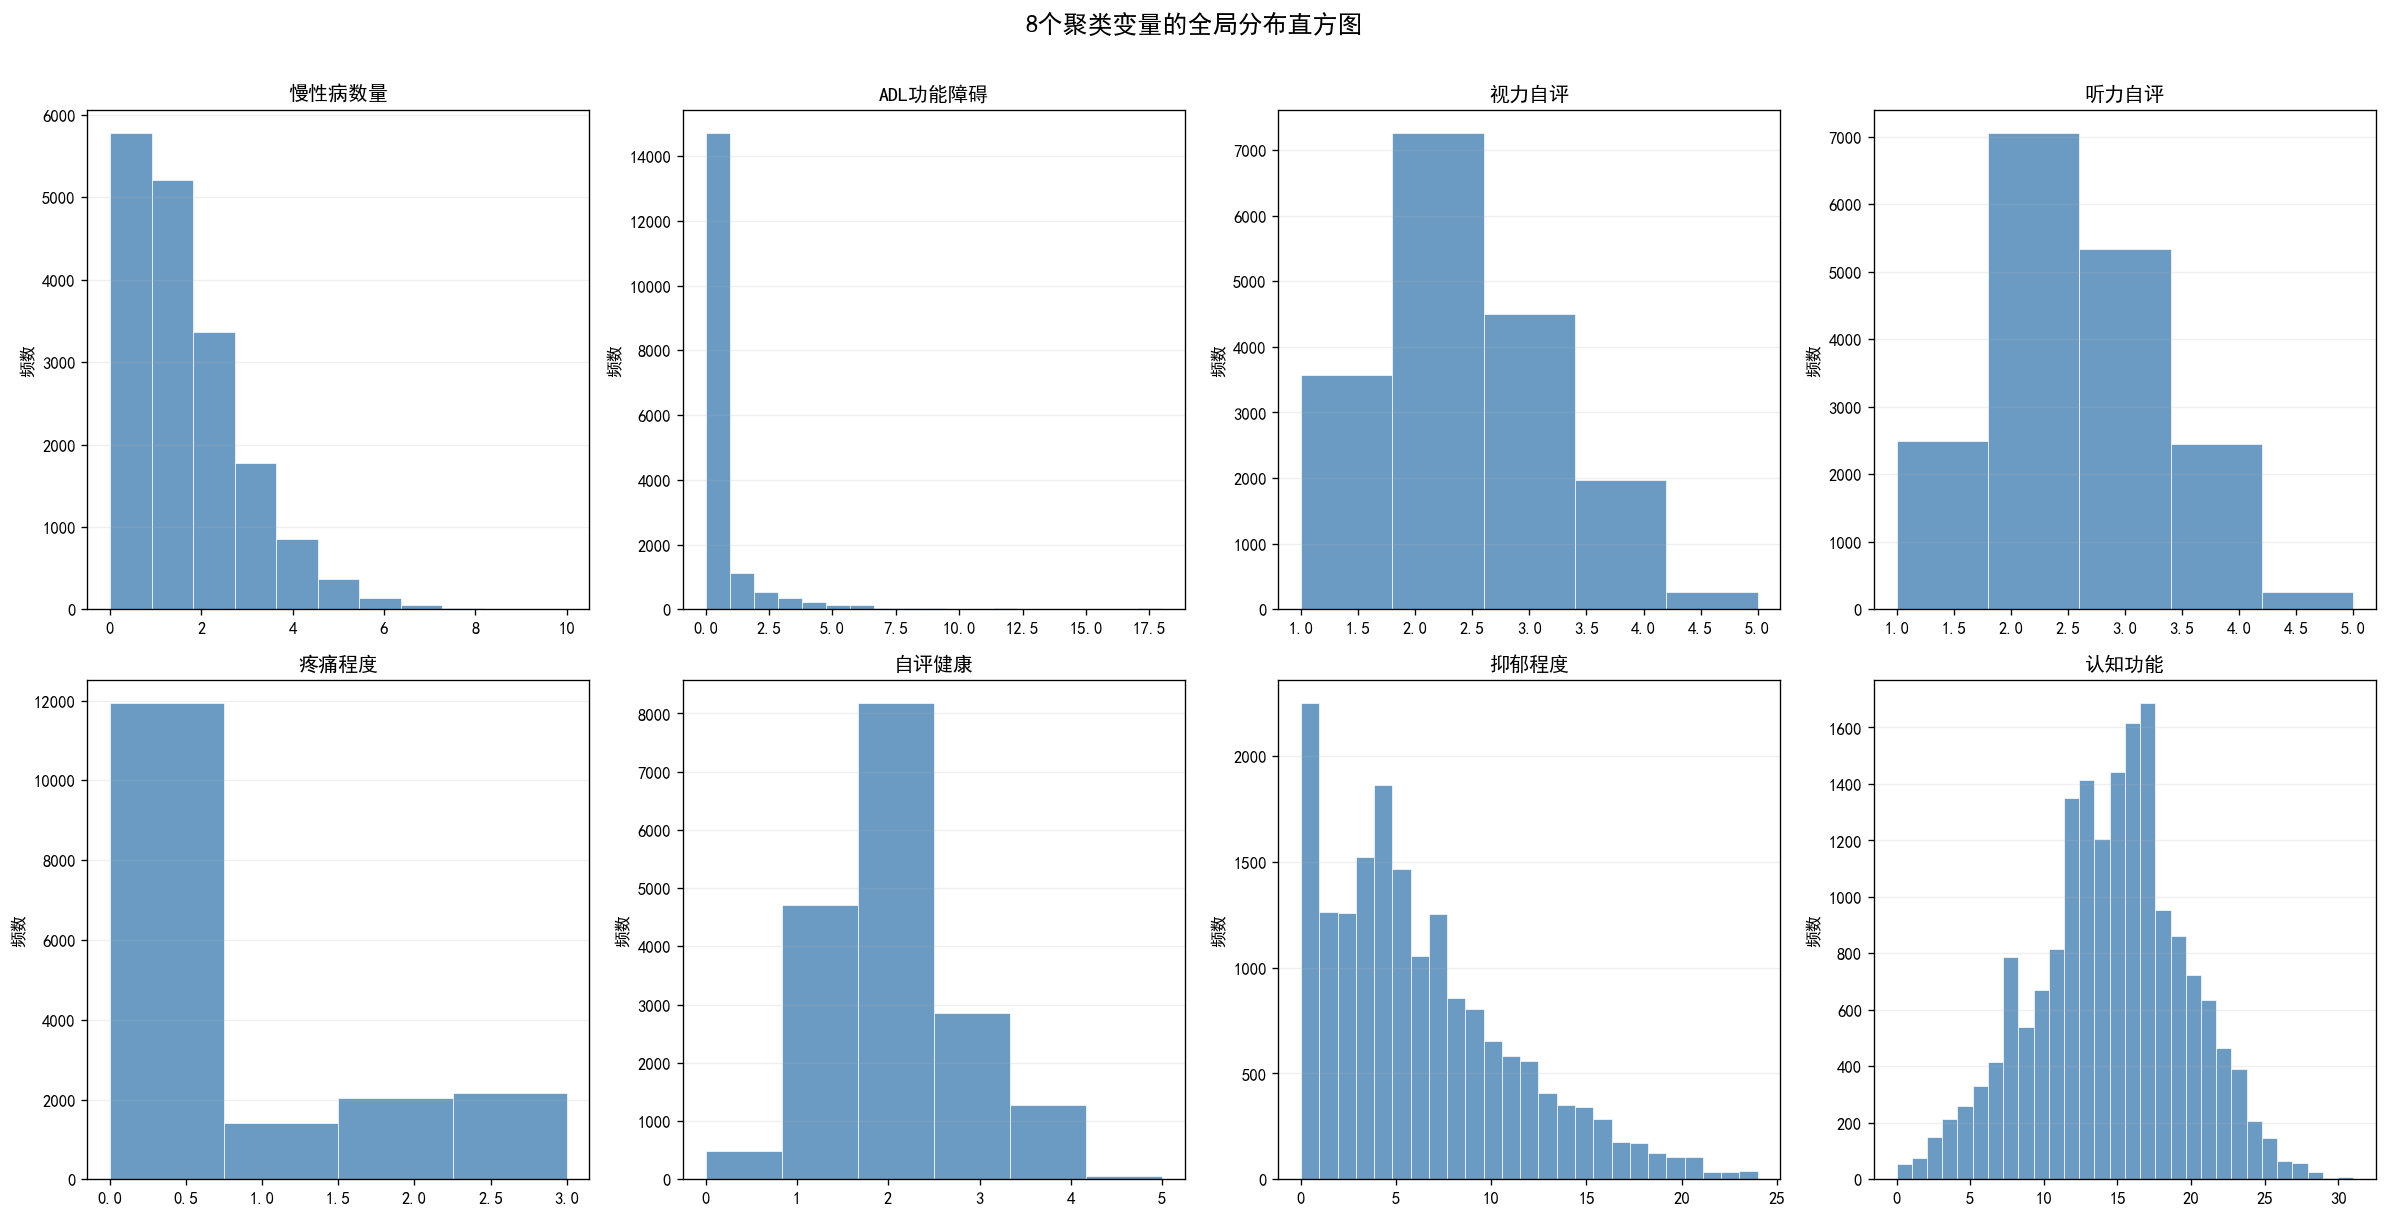


 分布形态解读：
  慢性病数量: 偏度=1.24 (右偏（低值集中）), 峰度=1.82 (单峰分布)
  ADL功能障碍: 偏度=5.57 (右偏（低值集中）), 峰度=37.96 (单峰分布)
  视力自评: 偏度=0.46 (近似对称), 峰度=-0.35 (可能存在双峰)
  听力自评: 偏度=0.29 (近似对称), 峰度=-0.47 (可能存在双峰)
  疼痛程度: 偏度=1.22 (右偏（低值集中）), 峰度=-0.14 (可能存在双峰)
  自评健康: 偏度=0.45 (近似对称), 峰度=0.12 (单峰分布)
  抑郁程度: 偏度=0.95 (右偏（低值集中）), 峰度=0.45 (单峰分布)
  认知功能: 偏度=-0.15 (近似对称), 峰度=-0.12 (可能存在双峰)


In [16]:
# 纯直方图，不加KDE（变量基本都是离散整数，柱子本身就够清楚）

print("\n" + "="*70)
print("第十一步：聚类变量全局分布直方图")
print("="*70)

cn_names = {
    'chronic_count': '慢性病数量',
    'adl_score': 'ADL功能障碍',
    'vision_score': '视力自评',
    'hearing_score': '听力自评',
    'pain_level': '疼痛程度',
    'srh': '自评健康',
    'cesd_score': '抑郁程度',
    'cognition_total': '认知功能'
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(cluster_vars):
    ax = axes[idx]
    # 根据变量范围自动设置bin数
    val_range = df[var].max() - df[var].min()
    bins = int(val_range) + 1 if val_range <= 30 else 30
    ax.hist(df[var], bins=bins, color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.8)
    ax.set_title(cn_names[var], fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('频数')
    ax.grid(True, alpha=0.2, axis='y')

fig.suptitle('8个聚类变量的全局分布直方图', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("\n 分布形态解读：")
for var in cluster_vars:
    skew = df[var].skew()
    kurt = df[var].kurtosis()
    shape = "右偏（低值集中）" if skew > 0.5 else ("左偏（高值集中）" if skew < -0.5 else "近似对称")
    bi = "可能存在双峰" if kurt < 0 else "单峰分布"
    print(f"  {cn_names[var]}: 偏度={skew:.2f} ({shape}), 峰度={kurt:.2f} ({bi})")

# ======================
# 第十一步续 分组分布对比（彩色直方图，不用KDE）
# ======================


 以 K=3（主推方案）绘制分组分布对比


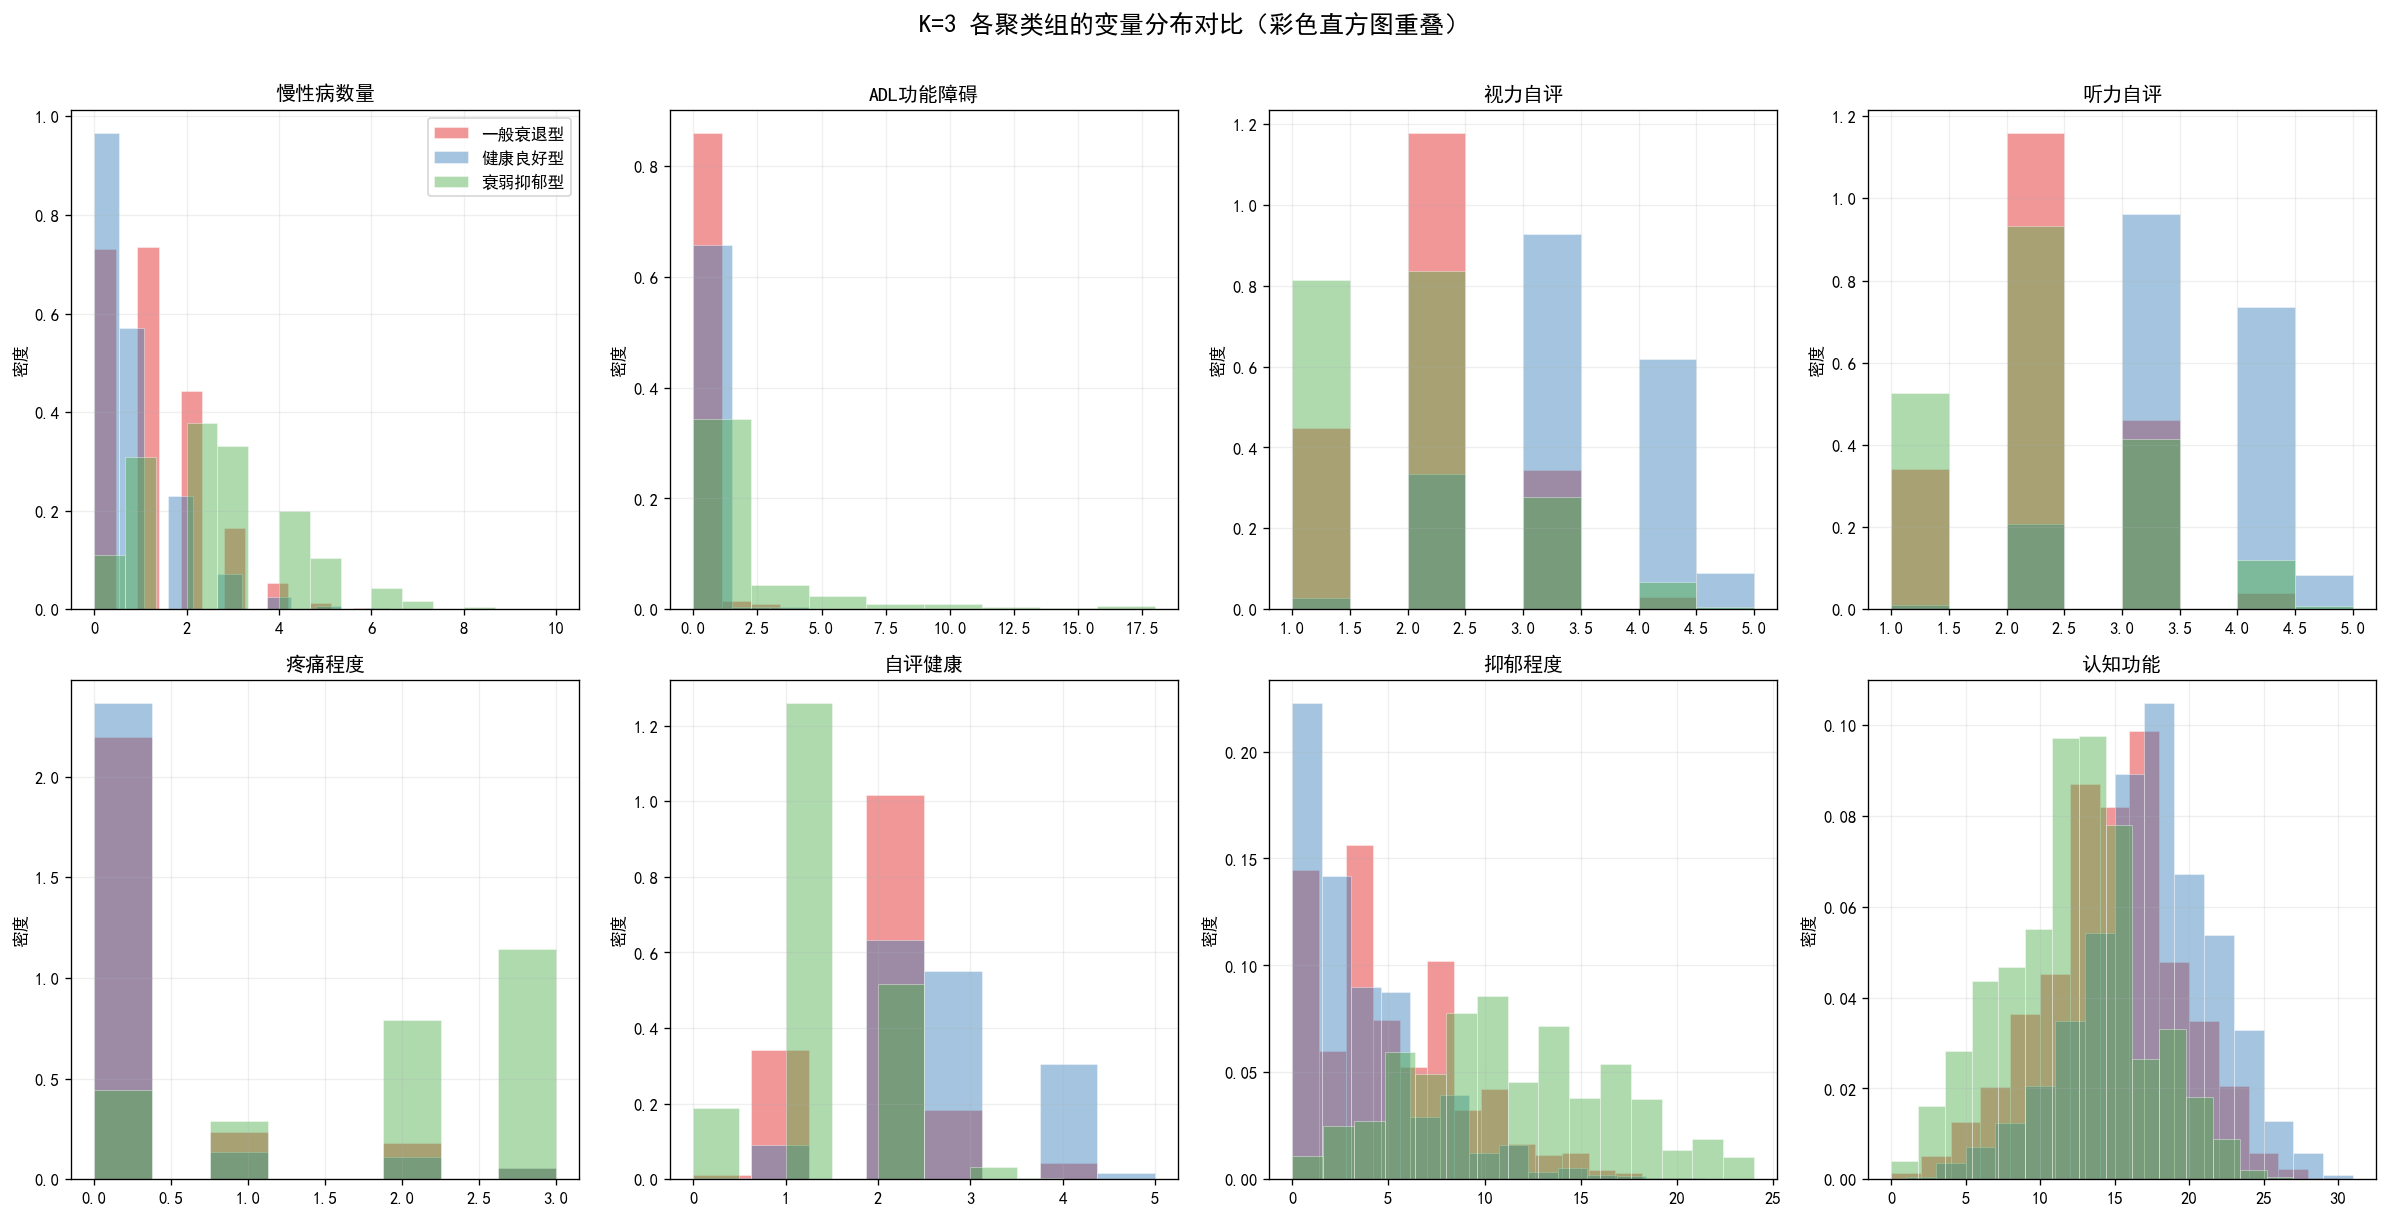


 按分组【一般衰退型, 健康良好型, 衰弱抑郁型】的分布差异解读：
  慢性病数量: 均值范围 0.75~2.55 (全样本均值=1.36)
    → 健康良好型最低(0.75)，衰弱抑郁型最高(2.55)，组间差距=1.80
  ADL功能障碍: 均值范围 0.07~1.80 (全样本均值=0.54)
    → 健康良好型最低(0.07)，衰弱抑郁型最高(1.80)，组间差距=1.73
  视力自评: 均值范围 1.81~3.20 (全样本均值=2.32)
    → 衰弱抑郁型最低(1.81)，健康良好型最高(3.20)，组间差距=1.40
  听力自评: 均值范围 2.08~3.34 (全样本均值=2.48)
    → 衰弱抑郁型最低(2.08)，健康良好型最高(3.34)，组间差距=1.26
  疼痛程度: 均值范围 0.20~1.99 (全样本均值=0.68)
    → 健康良好型最低(0.20)，衰弱抑郁型最高(1.99)，组间差距=1.79
  自评健康: 均值范围 1.20~2.70 (全样本均值=1.99)
    → 衰弱抑郁型最低(1.20)，健康良好型最高(2.70)，组间差距=1.50
  抑郁程度: 均值范围 3.55~11.20 (全样本均值=6.10)
    → 健康良好型最低(3.55)，衰弱抑郁型最高(11.20)，组间差距=7.66
  认知功能: 均值范围 12.06~16.83 (全样本均值=14.55)
    → 衰弱抑郁型最低(12.06)，健康良好型最高(16.83)，组间差距=4.77


In [15]:
# 如果你想用K=2或K=4，把下面 best_k_val 改成 2 或 4 即可
best_k_val = 3   # ← 这里改主推的K值
cluster_col = f'cluster_{best_k_val}'

# 定义各方案的聚类名称（从前面步骤提取）
if best_k_val == 2:
    cluster_names = names_2
elif best_k_val == 3:
    cluster_names = names_3
else:
    cluster_names = names_4

cn_names = {
    'chronic_count': '慢性病数量',
    'adl_score': 'ADL功能障碍',
    'vision_score': '视力自评',
    'hearing_score': '听力自评',
    'pain_level': '疼痛程度',
    'srh': '自评健康',
    'cesd_score': '抑郁程度',
    'cognition_total': '认知功能'
}

print(f"\n 以 K={best_k_val}（主推方案）绘制分组分布对比")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

palette = sns.color_palette('Set1', best_k_val)

# 因为很多变量是离散整数（1-5 Likert量表），KDE曲线会失真
# 改用彩色重叠直方图，更诚实地展示分布
for idx, var in enumerate(cluster_vars):
    ax = axes[idx]
    bins = 15 if var in ['chronic_count', 'cognition_total', 'cesd_score'] else 8
    for c in range(best_k_val):
        subset = df[df[cluster_col] == c][var]
        ax.hist(subset, bins=bins, density=True, alpha=0.45,
                color=palette[c], edgecolor='white', linewidth=0.5,
                label=cluster_names[c])
    ax.set_title(cn_names[var], fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('密度')
    if idx == 0:
        ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.2)

fig.suptitle(f'K={best_k_val} 各聚类组的变量分布对比（彩色直方图重叠）', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# 分布差异解读
print(f"\n 按分组【{', '.join(cluster_names)}】的分布差异解读：")
for var in cluster_vars:
    means_by_cluster = df.groupby(cluster_col)[var].mean()
    max_cluster = means_by_cluster.idxmax()
    min_cluster = means_by_cluster.idxmin()
    spread = means_by_cluster.max() - means_by_cluster.min()
    overall_mean = df[var].mean()
    print(f"  {cn_names[var]}: 均值范围 {means_by_cluster.min():.2f}~{means_by_cluster.max():.2f} (全样本均值={overall_mean:.2f})")
    print(f"    → {cluster_names[min_cluster]}最低({means_by_cluster.min():.2f})，{cluster_names[max_cluster]}最高({means_by_cluster.max():.2f})，组间差距={spread:.2f}")
